# 🦋 Énigmes & Merveilles d'Ian Stewart

*Un notebook démo pour matheux, dans l'esprit d'Ian Stewart — mathématicien à Warwick, successeur de
Martin Gardner à la rubrique « Mathematical Recreations » du *Scientific American*, spécialiste de la
théorie des singularités et de la symétrie (*Fearful Symmetry*, *Why Beauty Is Truth*), vulgarisateur du
chaos (*Does God Play Dice?*) et auteur de dizaines d'ouvrages de récréations mathématiques
(*Cabinet of Mathematical Curiosities*, *Professor Stewart's Hoard of Mathematical Treasures*).*

Troisième volet de la série de démos JupyterLab, après Pickover et Gardner — **9 explorations** ancrées
dans les grands thèmes de l'œuvre de Stewart : symétrie, morphogenèse, chaos, catastrophes et topologie.

**Sommaire**

1. [Symétries et groupes de papier peint](#1)
2. [Motifs de Turing (réaction-diffusion)](#2)
3. [Phyllotaxie et angle d'or](#3)
4. [Théorème des quatre couleurs](#4)
5. [Théorie des catastrophes — la fronce](#5)
6. [Attracteur de Lorenz](#6)
7. [Les mathématiques du jonglage](#7)
8. [Théorie des nœuds — le trèfle](#8)
9. [Le problème du passeur (loup, chèvre, chou)](#9)
10. [Bac à sable interactif](#10)

> 💡 Astuce démo : `Run All Cells` en ouverture, tout se recalcule sous les yeux du public.


## 1. Symétries et groupes de papier peint <a id="1"></a>

La symétrie est *le* fil conducteur de l'œuvre de Stewart — *Fearful Symmetry* (avec Martin Golubitsky) et
*Why Beauty Is Truth* en font le sujet central. Il existe exactement **17 groupes de papier peint**
(*wallpaper groups*) classifiant toutes les façons de paver le plan avec une symétrie répétitive. On peut
en générer un directement en sommant des ondes planes orientées selon les axes de symétrie voulus — ici,
trois directions à 60° l'une de l'autre produisent une symétrie hexagonale de type **p6m**.

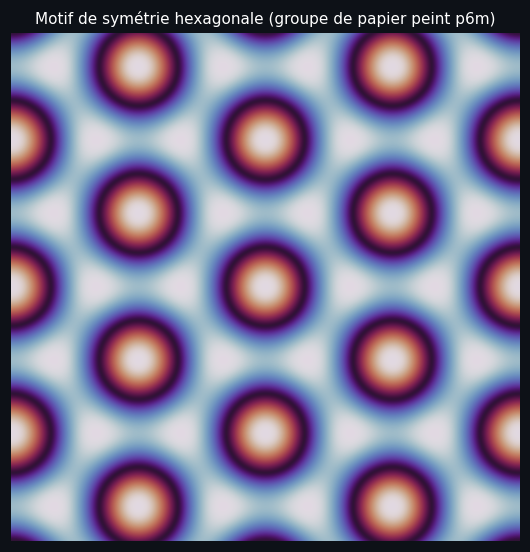

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

n = 500
x = np.linspace(-4*np.pi, 4*np.pi, n)
X, Y = np.meshgrid(x, x)
angles = [0, math.pi/3, 2*math.pi/3]
Z = np.zeros_like(X)
for a in angles:
    Z += np.cos(X*np.cos(a) + Y*np.sin(a))

fig, ax = plt.subplots(figsize=(6,6), facecolor="#0d1117")
ax.imshow(Z, cmap="twilight", extent=[-4,4,-4,4])
ax.set_axis_off()
ax.set_title("Motif de symétrie hexagonale (groupe de papier peint p6m)", color="white", fontsize=10)
plt.show()


## 2. Motifs de Turing (réaction-diffusion) <a id="2"></a>

Dans *The Mathematics of Life* et plusieurs de ses articles, Stewart revient sur l'idée d'Alan Turing
(1952) : les motifs de pelage animal — taches de léopard, rayures de zèbre, réseaux de girafe — peuvent
émerger spontanément de deux substances chimiques qui diffusent et réagissent l'une avec l'autre à des
vitesses différentes. C'est le modèle de **Gray-Scott**, une des variantes computationnelles les plus
populaires de cette idée de "morphogenèse".

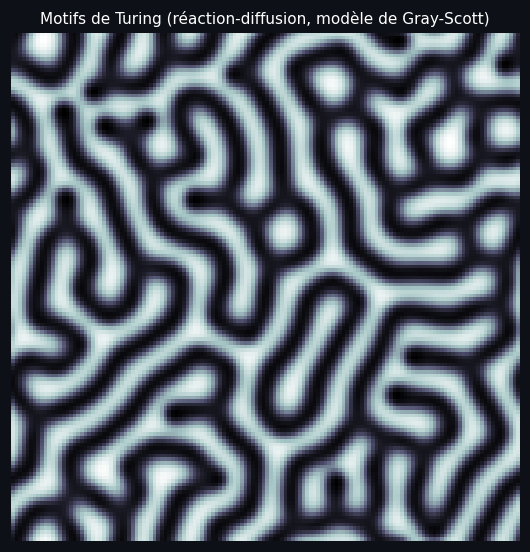

In [2]:
n = 140
np.random.seed(0)
U = np.ones((n,n)); V = np.zeros((n,n))
for _ in range(6):
    cx, cy = np.random.randint(20,n-20,2)
    U[cx-5:cx+5, cy-5:cy+5] = 0.5
    V[cx-5:cx+5, cy-5:cy+5] = 0.25
U += 0.02*np.random.random((n,n)); V += 0.02*np.random.random((n,n))

def laplacian(Z):
    return (-4*Z + np.roll(Z,1,0)+np.roll(Z,-1,0)+np.roll(Z,1,1)+np.roll(Z,-1,1))

Du, Dv, f, k = 0.16, 0.08, 0.060, 0.062  # paramètres type "corail"
for i in range(7000):
    Lu, Lv = laplacian(U), laplacian(V)
    UVV = U*V*V
    U += (Du*Lu - UVV + f*(1-U))
    V += (Dv*Lv + UVV - (f+k)*V)

fig, ax = plt.subplots(figsize=(6,6), facecolor="#0d1117")
ax.imshow(U, cmap="bone")
ax.set_axis_off()
ax.set_title("Motifs de Turing (réaction-diffusion, modèle de Gray-Scott)", color="white", fontsize=10)
plt.show()


## 3. Phyllotaxie et angle d'or <a id="3"></a>

Dans *Life's Other Secret*, Stewart explore en détail pourquoi les graines de tournesol, les écailles de
pomme de pin ou les pétales de marguerite s'organisent en spirales dont le nombre suit presque toujours la
suite de Fibonacci. La clé : un angle de divergence entre graines successives égal à l'**angle d'or**
$\approx 137{,}5°$ — le seul angle qui empêche les spirales de s'aligner et permet un compactage optimal.

angle d'or = 2.399963 rad = 137.5078°


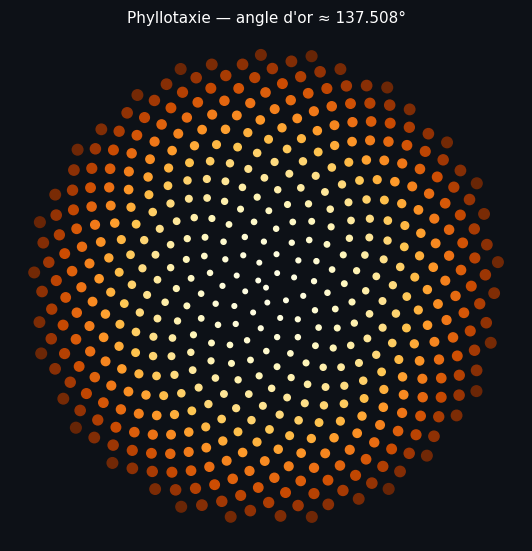

In [3]:
golden_angle = np.pi*(3 - 5**0.5)
print(f"angle d'or = {golden_angle:.6f} rad = {np.degrees(golden_angle):.4f}°")

N = 500
idx = np.arange(N)
r = np.sqrt(idx)
theta = idx*golden_angle
xs, ys = r*np.cos(theta), r*np.sin(theta)

fig, ax = plt.subplots(figsize=(6,6), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.scatter(xs, ys, s=(idx/N*40+8), c=idx, cmap="YlOrBr")
ax.set_aspect("equal"); ax.set_axis_off()
ax.set_title(f"Phyllotaxie — angle d'or ≈ {np.degrees(golden_angle):.3f}°", color="white", fontsize=10)
plt.show()


## 4. Théorème des quatre couleurs <a id="4"></a>

Stewart revient régulièrement sur ce théorème — quatre couleurs suffisent toujours à colorier une carte
politique pour que deux régions voisines n'aient jamais la même couleur — notamment pour discuter de sa
démonstration de 1976 par Appel et Haken, la première grande preuve mathématique reposant essentiellement
sur une vérification exhaustive par ordinateur, ce qui a soulevé (et soulève encore) des questions
philosophiques sur ce qu'est une "preuve". Ci-dessous : une carte aléatoire (triangulation de Delaunay) et
sa coloration à 4 couleurs trouvée par recherche avec retour arrière.

Régions : 30   Arêtes : 80   Couleurs utilisées : 4


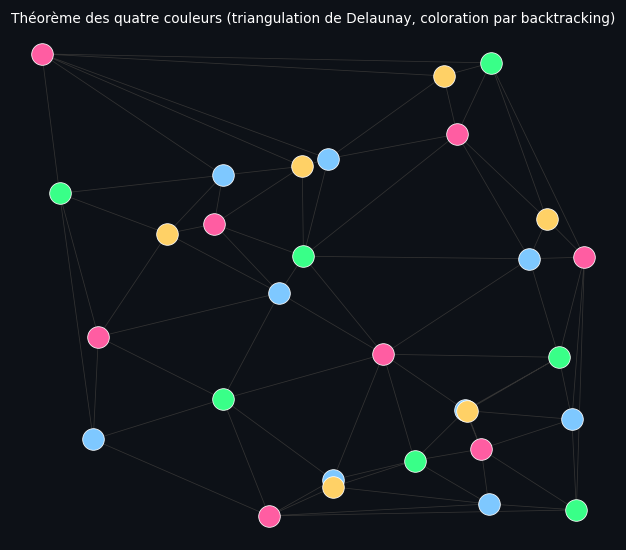

In [4]:
from scipy.spatial import Delaunay

rng = np.random.default_rng(3)
npts = 30
pts = rng.random((npts,2))*10
tri = Delaunay(pts)

adj = {i:set() for i in range(npts)}
for simplex in tri.simplices:
    for a in range(3):
        for b in range(3):
            if a != b: adj[simplex[a]].add(simplex[b])

colors = {}
order = sorted(adj.keys(), key=lambda k: -len(adj[k]))
def color_ok(node, c): return all(colors.get(nb) != c for nb in adj[node])
def backtrack(i):
    if i == len(order): return True
    node = order[i]
    for c in range(4):
        if color_ok(node, c):
            colors[node] = c
            if backtrack(i+1): return True
            del colors[node]
    return False

backtrack(0)
print(f"Régions : {npts}   Arêtes : {sum(len(v) for v in adj.values())//2}   "
      f"Couleurs utilisées : {len(set(colors.values()))}")

palette = ["#ff5da2","#39ff88","#7ec8ff","#ffd166"]
fig, ax = plt.subplots(figsize=(7,6), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.triplot(pts[:,0], pts[:,1], tri.simplices, color="#333", lw=0.5)
for i,(px,py) in enumerate(pts):
    ax.scatter(px, py, color=palette[colors[i]], s=200, zorder=3, edgecolor="white", linewidth=0.5)
ax.set_axis_off()
ax.set_title("Théorème des quatre couleurs — coloration par backtracking", color="white", fontsize=10)
plt.show()


## 5. Théorie des catastrophes — la fronce <a id="5"></a>

Sujet aux racines personnelles pour Stewart : sa thèse de doctorat sous la direction de Christopher Zeeman
portait sur la **théorie des singularités**, dont la théorie des catastrophes (popularisée dans les années
1970 par René Thom et Zeeman) est une application spectaculaire — il en co-écrit d'ailleurs un ouvrage de
référence. La **catastrophe en fronce** (*cusp*) décrit comment un système à un seul état d'équilibre peut
brutalement en acquérir deux (bistabilité), avec des sauts discontinus quand on franchit certaines
frontières de paramètres — modèle classique pour les changements brusques de comportement (agression
animale, effondrements financiers, transitions de phase).

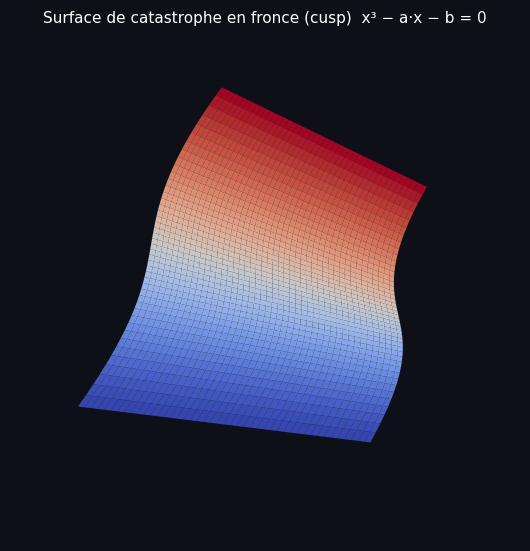

In [5]:
from mpl_toolkits.mplot3d import Axes3D

a = np.linspace(-2.2, 2.2, 220)
xg = np.linspace(-2.2, 2.2, 220)
A, Xg = np.meshgrid(a, xg)
B = Xg**3 - A*Xg   # surface d'équilibre : x³ − a·x − b = 0

fig = plt.figure(figsize=(7,6), facecolor="#0d1117")
ax = fig.add_subplot(111, projection='3d', facecolor="#0d1117")
ax.plot_surface(A, B, Xg, cmap="coolwarm", linewidth=0, antialiased=True, alpha=0.9)
ax.set_axis_off()
ax.set_title("Surface de catastrophe en fronce  x³ − a·x − b = 0", color="white", fontsize=10)
plt.show()


## 6. Attracteur de Lorenz <a id="6"></a>

Dans *Does God Play Dice? The Mathematics of Chaos*, Stewart offre l'une des vulgarisations les plus
lues de la théorie du chaos. L'exemple canonique reste le système d'Edward Lorenz (1963), un modèle
météorologique simplifié à seulement trois équations différentielles, dont les trajectoires ne se
recoupent jamais mais restent confinées sur une structure fractale en forme d'ailes de papillon —
l'origine même de l'expression "effet papillon".

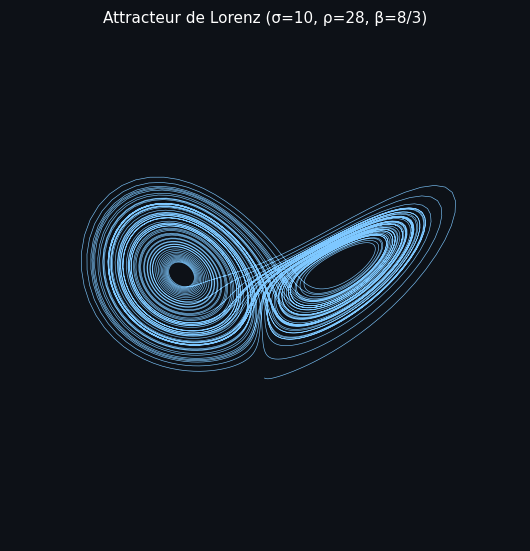

In [6]:
def lorenz_d(xyz, s=10, r=28, b=8/3):
    x,y,z = xyz
    return np.array([s*(y-x), x*(r-z)-y, x*y-b*z])

dt, n = 0.01, 8000
xyz = np.empty((n,3)); xyz[0] = (0., 1., 1.05)
for i in range(n-1):
    k1 = lorenz_d(xyz[i])
    k2 = lorenz_d(xyz[i]+dt/2*k1)
    k3 = lorenz_d(xyz[i]+dt/2*k2)
    k4 = lorenz_d(xyz[i]+dt*k3)
    xyz[i+1] = xyz[i] + dt/6*(k1+2*k2+2*k3+k4)

fig = plt.figure(figsize=(7,6), facecolor="#0d1117")
ax = fig.add_subplot(111, projection='3d', facecolor="#0d1117")
ax.plot(xyz[:,0], xyz[:,1], xyz[:,2], color="#7ec8ff", lw=0.4)
ax.set_axis_off()
ax.set_title("Attracteur de Lorenz (σ=10, ρ=28, β=8/3)", color="white", fontsize=10)
plt.show()


## 7. Les mathématiques du jonglage <a id="7"></a>

Stewart a consacré une chronique à la notation **siteswap**, développée indépendamment à la fin des années
1980 par plusieurs jongleurs-mathématiciens, qui code un motif de jonglage par une suite de nombres
indiquant, à chaque battement, dans combien de temps la balle lancée doit retomber. Le motif "3" décrit la
**cascade** classique à 3 balles ; des séquences comme "531" décrivent des motifs bien plus acrobatiques,
toutes soumises à une contrainte purement arithmétique : la moyenne des chiffres doit être un entier égal
au nombre de balles.

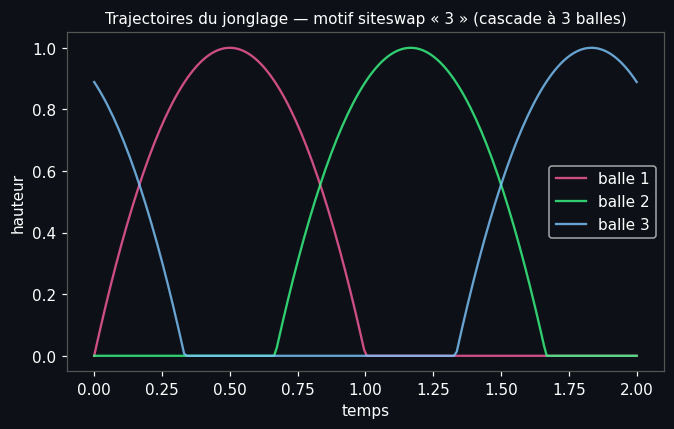

In [7]:
fig, ax = plt.subplots(figsize=(7,4), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
colors_b = ["#ff5da2","#39ff88","#7ec8ff"]
for k,phase in enumerate([0, 2/3, 4/3]):
    t = np.linspace(0,2,200)
    tau = (t - phase) % 2
    height = np.where(tau<=1, 4*tau*(1-tau), 0)
    ax.plot(t, height, color=colors_b[k], alpha=0.8, label=f"balle {k+1}")
ax.set_xlabel("temps", color="white"); ax.set_ylabel("hauteur", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.legend(facecolor="#0d1117", labelcolor="white")
ax.set_title('Trajectoires du jonglage — motif siteswap "3" (cascade à 3 balles)', color="white", fontsize=10)
plt.show()


## 8. Théorie des nœuds — le trèfle <a id="8"></a>

La topologie des nœuds apparaît dans plusieurs des livres de Stewart (*Game, Set and Math*, *Visions of
Infinity*) comme exemple parfait de mathématiques "qui se voient" : deux nœuds sont équivalents si on peut
déformer l'un en l'autre sans jamais couper la corde. Le **nœud de trèfle** est le plus simple des nœuds
non triviaux — impossible à démêler en un simple cercle, contrairement à ce que l'intuition suggère parfois
au premier coup d'œil.

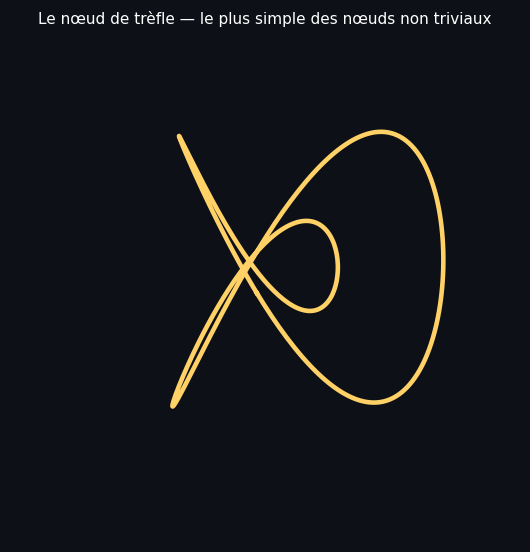

In [8]:
from mpl_toolkits.mplot3d import Axes3D

t = np.linspace(0, 2*np.pi, 400)
x = np.sin(t) + 2*np.sin(2*t)
y = np.cos(t) - 2*np.cos(2*t)
z = -np.sin(3*t)

fig = plt.figure(figsize=(6,6), facecolor="#0d1117")
ax = fig.add_subplot(111, projection='3d', facecolor="#0d1117")
ax.plot(x, y, z, color="#ffd166", lw=3)
ax.set_axis_off()
ax.set_title("Le nœud de trèfle — le plus simple des nœuds non triviaux", color="white", fontsize=10)
plt.show()


## 9. Le problème du passeur (loup, chèvre, chou) <a id="9"></a>

Stewart adore les généralisations de ce casse-tête médiéval dans ses recueils (*Cabinet of Mathematical
Curiosities* propose par exemple la variante des "maris jaloux"). Un passeur doit faire traverser une
rivière à un loup, une chèvre et un chou, sa barque ne pouvant transporter qu'un seul élément à la fois, et
ne pouvant jamais laisser ensemble sans surveillance le loup avec la chèvre, ni la chèvre avec le chou. On
résout cela élégamment par une recherche en largeur (**BFS**) dans le graphe des états possibles.

In [9]:
from collections import deque

def safe(state):
    f, w, g, c = state
    if g == w and g != f: return False
    if g == c and g != f: return False
    return True

start, goal = (0,0,0,0), (1,1,1,1)
Q = deque([(start, [])])
seen = {start}
found = None
while Q:
    state, path = Q.popleft()
    if state == goal:
        found = path
        break
    f, w, g, c = state
    items = []
    if w == f: items.append('loup')
    if g == f: items.append('chèvre')
    if c == f: items.append('chou')
    items.append(None)
    for it in items:
        ns = list(state); ns[0] = 1 - f
        if it == 'loup':   ns[1] = 1 - w
        if it == 'chèvre': ns[2] = 1 - g
        if it == 'chou':   ns[3] = 1 - c
        ns = tuple(ns)
        if safe(ns) and ns not in seen:
            seen.add(ns)
            Q.append((ns, path + [it]))

print("Solution en", len(found), "traversées :")
for i, item in enumerate(found, 1):
    print(f"  {i}. le passeur emmène : {item if item else '(rien, traversée à vide)'}")


Solution en 7 traversées :
  1. le passeur emmène : chèvre
  2. le passeur emmène : (rien, traversée à vide)
  3. le passeur emmène : loup
  4. le passeur emmène : chèvre
  5. le passeur emmène : chou
  6. le passeur emmène : (rien, traversée à vide)
  7. le passeur emmène : chèvre


## 10. Bac à sable interactif <a id="10"></a>

Pour la démo live : sliders `ipywidgets` pour explorer en temps réel deux systèmes emblématiques de
Stewart — les paramètres $(\rho)$ de l'attracteur de Lorenz (voir la transition vers le chaos en direct),
et les paramètres $(f,k)$ du modèle de Gray-Scott pour faire apparaître différentes familles de motifs de
Turing (taches, rayures, labyrinthes).

> ⚠️ Nécessite `ipywidgets` installé et activé dans l'environnement JupyterLab (`pip install ipywidgets`).

In [ ]:
from ipywidgets import interact, FloatSlider

def plot_lorenz(rho=28.0, sigma=10.0, beta_num=8.0, beta_den=3.0, n=6000):
    beta = beta_num/beta_den
    def d(xyz):
        x,y,z = xyz
        return np.array([sigma*(y-x), x*(rho-z)-y, x*y-beta*z])
    dt = 0.01
    xyz = np.empty((n,3)); xyz[0] = (0.,1.,1.05)
    for i in range(n-1):
        k1=d(xyz[i]); k2=d(xyz[i]+dt/2*k1); k3=d(xyz[i]+dt/2*k2); k4=d(xyz[i]+dt*k3)
        xyz[i+1] = xyz[i] + dt/6*(k1+2*k2+2*k3+k4)
    fig = plt.figure(figsize=(6,6), facecolor="#0d1117")
    ax = fig.add_subplot(111, projection='3d', facecolor="#0d1117")
    ax.plot(xyz[:,0], xyz[:,1], xyz[:,2], color="#7ec8ff", lw=0.4)
    ax.set_axis_off()
    ax.set_title(f"Lorenz — ρ={rho:.1f}  σ={sigma:.1f}  β={beta:.2f}", color="white")
    plt.show()

interact(plot_lorenz,
         rho=FloatSlider(28.0, min=0, max=60, step=1),
         sigma=FloatSlider(10.0, min=1, max=30, step=1),
         beta_num=FloatSlider(8.0, min=1, max=20, step=1),
         beta_den=FloatSlider(3.0, min=1, max=10, step=1))


## Pour aller plus loin

Quelques pistes de lecture pour prolonger la démo :

- **Ian Stewart**, *Does God Play Dice? The Mathematics of Chaos* (1989) — Lorenz, attracteurs, chaos
- **Ian Stewart & Martin Golubitsky**, *Fearful Symmetry: Is God a Geometer?* (1992) — symétrie et morphogenèse
- **Ian Stewart**, *Why Beauty Is Truth: A History of Symmetry* (2007)
- **Ian Stewart**, *The Mathematics of Life* (2011) — Turing, biologie mathématique
- **Ian Stewart**, *Cabinet of Mathematical Curiosities* (2008) et *Professor Stewart's Hoard of Mathematical Treasures* (2009)
- **Ian Stewart**, *Visions of Infinity* (2013) — grands problèmes non résolus, dont le théorème des quatre couleurs

---
*Troisième notebook de la série démo JupyterLab (après Pickover et Gardner) — libre à toi de piocher,
couper, ou dupliquer les cellules selon le public visé.*
